In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
import numpy as np
from numpy.polynomial.polynomial import polyvander2d
from numpy.polynomial.polynomial import polyfit, polyval2d, polyval
from copy import deepcopy
from functools import partial
import yaml

def fit_poly2d(x, y, z, deg=3):
    """
    Fit a 2D polynomial z(x, y) of total degree 'deg' using NumPy's polyvander2d.
    Returns a 2D array of coefficients usable by polyval2d.
    """
    # Generate Vandermonde matrix
    V = polyvander2d(x, y, [deg, deg])

    # Solve least-squares fit
    coeffs, *_ = np.linalg.lstsq(V, z, rcond=None)

    # Reshape to 2D coefficient matrix
    coeffs = coeffs.reshape((deg + 1, deg + 1))
    return coeffs

def pad_coeffs(c1, c2):
    """Pad two 2D coefficient arrays to the same shape with zeros."""
    max_rows = max(c1.shape[0], c2.shape[0])
    max_cols = max(c1.shape[1], c2.shape[1])
    padded_c1 = np.zeros((max_rows, max_cols))
    padded_c2 = np.zeros((max_rows, max_cols))
    padded_c1[:c1.shape[0], :c1.shape[1]] = c1
    padded_c2[:c2.shape[0], :c2.shape[1]] = c2
    return padded_c1, padded_c2

In [114]:


# Replace with your actual filename
filename = "LT_ZEMAX_SURVEY_B_to_guillem_251013.pkl"

# Load the pickle file
df = pd.read_pickle(filename)
df = df.dropna(subset=["Elevation", "Rotator"])

# Choose which field to fit, e.g. dX
x = df["Elevation"].to_numpy(dtype=float)
y = df["Rotator"].to_numpy(dtype=float)


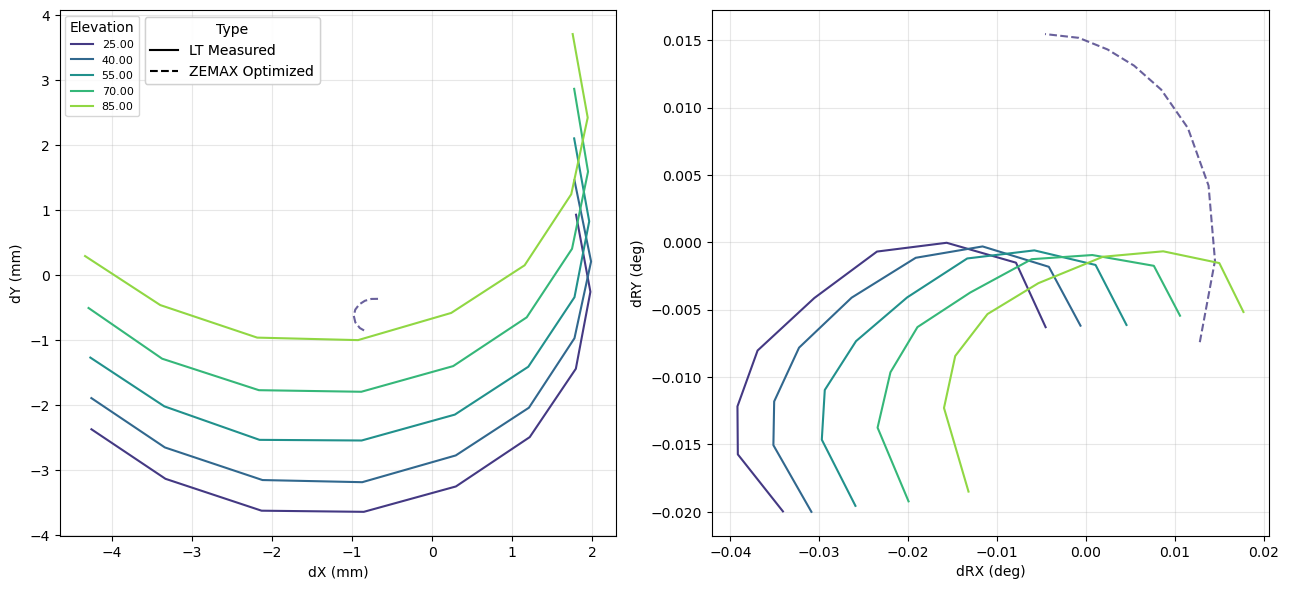

In [115]:
# Prepare palettes
elevations = sorted(df["Elevation"].dropna().unique())
palette_dxdy = sns.color_palette("viridis", len(elevations))
palette_ardefl = sns.color_palette("rocket", len(elevations))
elevations = sorted(df["Elevation"].dropna().unique())
palette = sns.color_palette("viridis", len(elevations))
# --- Plot setup ---
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for el, color in zip(elevations, palette):
    sub = df[df["Elevation"] == el]

    # Solid line: measured
    axes[0].plot(sub["dX"], sub["dY"], '-', label=f"{el}", alpha=1.0, color=color)

    # Dashed line: optimized (AR deflection)
    if float(el) == 25.0:
        axes[0].plot(sub["AR defl targ dX"], sub["AR defl targ dY"], '--', alpha=0.8, color=color)

# Axis labels and title
axes[0].set_xlabel("dX (mm)")
axes[0].set_ylabel("dY (mm)")
axes[0].grid(True, alpha=0.3)

# --- Legend setup ---
# First legend: elevations (colors)
elev_legend = axes[0].legend(title="Elevation", fontsize=8, loc="upper left", bbox_to_anchor=(0.0, 1.0))

# Second legend: line styles (measured vs optimized)
measured_line = mlines.Line2D([], [], color="black", linestyle='-', label="LT Measured")
optimized_line = mlines.Line2D([], [], color="black", linestyle='--', label="ZEMAX Optimized")
style_legend = axes[0].legend(handles=[measured_line, optimized_line], title="Type", loc="upper left", bbox_to_anchor=(0.14, 1.0))

# Add both legends
axes[0].add_artist(elev_legend)
axes[0].add_artist(style_legend)


for el, color in zip(elevations, palette):
    sub = df[df["Elevation"] == el]

    # Solid line: measured
    axes[1].plot(sub["dRX"], sub["dRY"], '-', label=f"{el}", alpha=1.0, color=color)

    # Dashed line: optimized (AR deflection)
    if float(el) == 25.00:
        axes[1].plot(sub["AR defl targ dRX"], sub["AR defl targ dRY"], '--', alpha=0.8, color=color)

# Axis labels and title
axes[1].set_xlabel("dRX (deg)")
axes[1].set_ylabel("dRY (deg)")
axes[1].grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

Processing AR defl targ dX...
Processing AR defl targ dY...
Processing AR defl targ dZ...
Processing AR defl targ dRX...
Processing AR defl targ dRY...


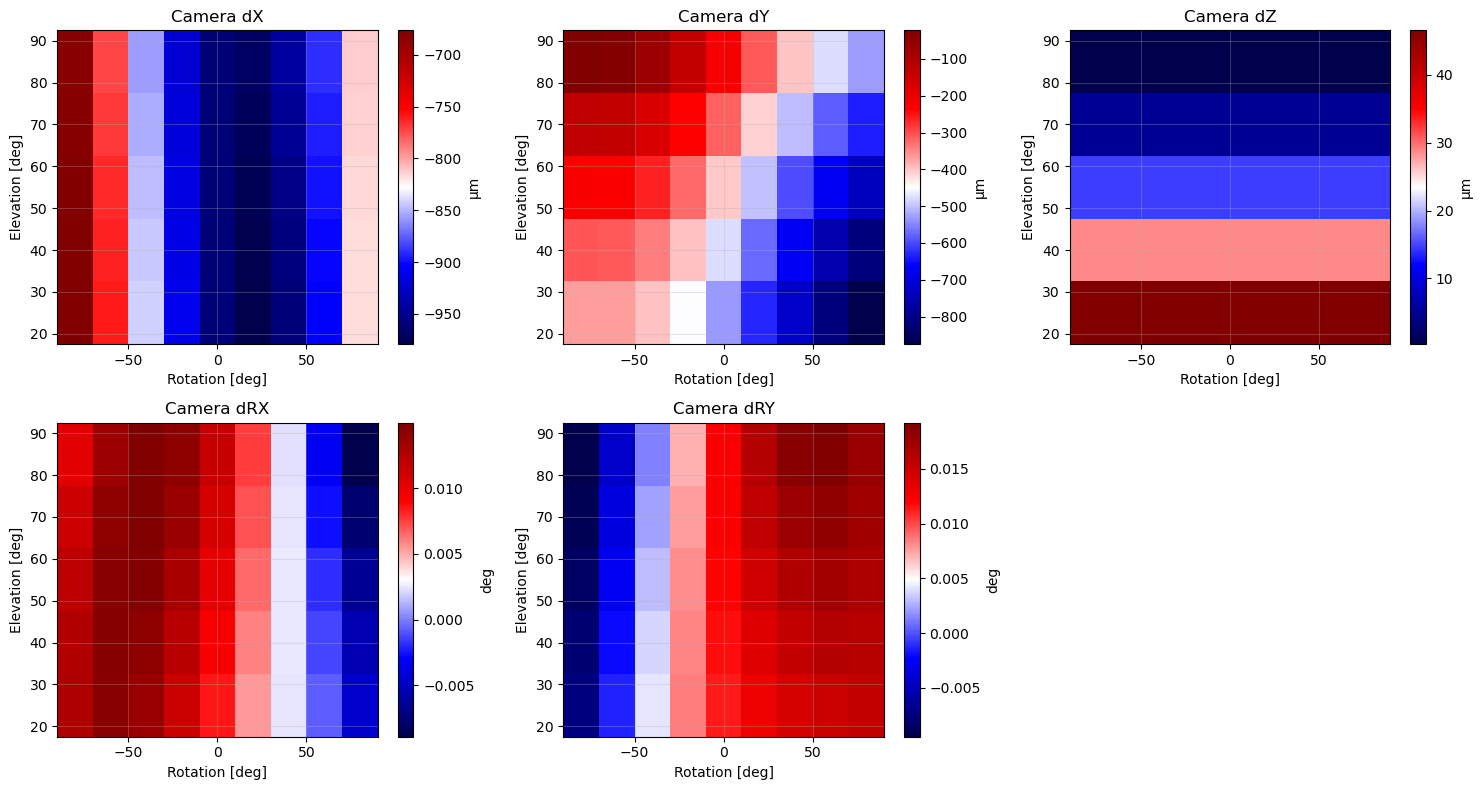

In [84]:
# Make sure Elevation and Rotator are numeric
df["Elevation"] = pd.to_numeric(df["Elevation"])
df["Rotator"]   = pd.to_numeric(df["Rotator"])

# Create a mesh grid
x_unique = np.sort(df["Rotator"].unique())
y_unique = np.sort(df["Elevation"].unique())

X, Y = np.meshgrid(x_unique, y_unique)

plt.figure(figsize=(15, 8))

for idx, field in enumerate(fields_n):
    Z = df.pivot_table(index="Elevation", columns="Rotator", values=field).to_numpy()

    ax = plt.subplot(2, 3, idx + 1)
    if idx < 3:
        surf = ax.pcolormesh(X, Y, Z*1000, shading="auto", cmap="seismic")
        plt.colorbar(surf, ax=ax, label="µm")
    else:
        surf = ax.pcolormesh(X, Y, Z, shading="auto", cmap="seismic")
        plt.colorbar(surf, ax=ax, label="deg")

    ax.set_title(f"Camera {field_labels[idx]}")
    ax.set_xlabel("Rotation [deg]")
    ax.set_ylabel("Elevation [deg]")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

dX: [[-1.29956022e+03 -5.44338781e+01  3.36038142e-01  2.52634737e-03
  -9.26523951e-06 -8.46363619e-10]
 [-1.23932021e+00 -8.89047853e-03  4.71481469e-04  6.31217845e-06
  -7.70967718e-08 -8.21527982e-10]
 [ 2.31725581e-02  2.47797283e-04 -4.64816941e-06 -1.06142497e-07
   6.92150005e-10  9.94256760e-12]
 [ 3.90449175e-13 -4.22707497e-07  0.00000000e+00  5.75638706e-11
   0.00000000e+00  0.00000000e+00]]
--------------------
dY: [[ 3.15756793e+03 -3.24738161e+01 -4.90241272e-01  1.86429768e-03
   1.23409336e-05 -7.25389478e-08]
 [-1.93040093e+01 -7.52778333e-02  2.81331618e-04  1.38072365e-05
  -4.30455130e-08 -1.06685853e-09]
 [-1.44611554e-01  5.88338125e-04 -1.63390005e-06 -1.00748287e-07
   2.91189337e-10  6.85909662e-12]
 [-2.75932838e-04 -4.48327193e-18 -4.04109368e-09  1.42584816e-16
   0.00000000e+00  0.00000000e+00]]
--------------------
dZ: [[-5.26167806e+02 -4.70554033e-01 -4.67952745e-03  6.22198935e-05]
 [ 1.74671832e+01  1.74164117e-02  9.49438429e-05 -1.93302750e-06]
 [

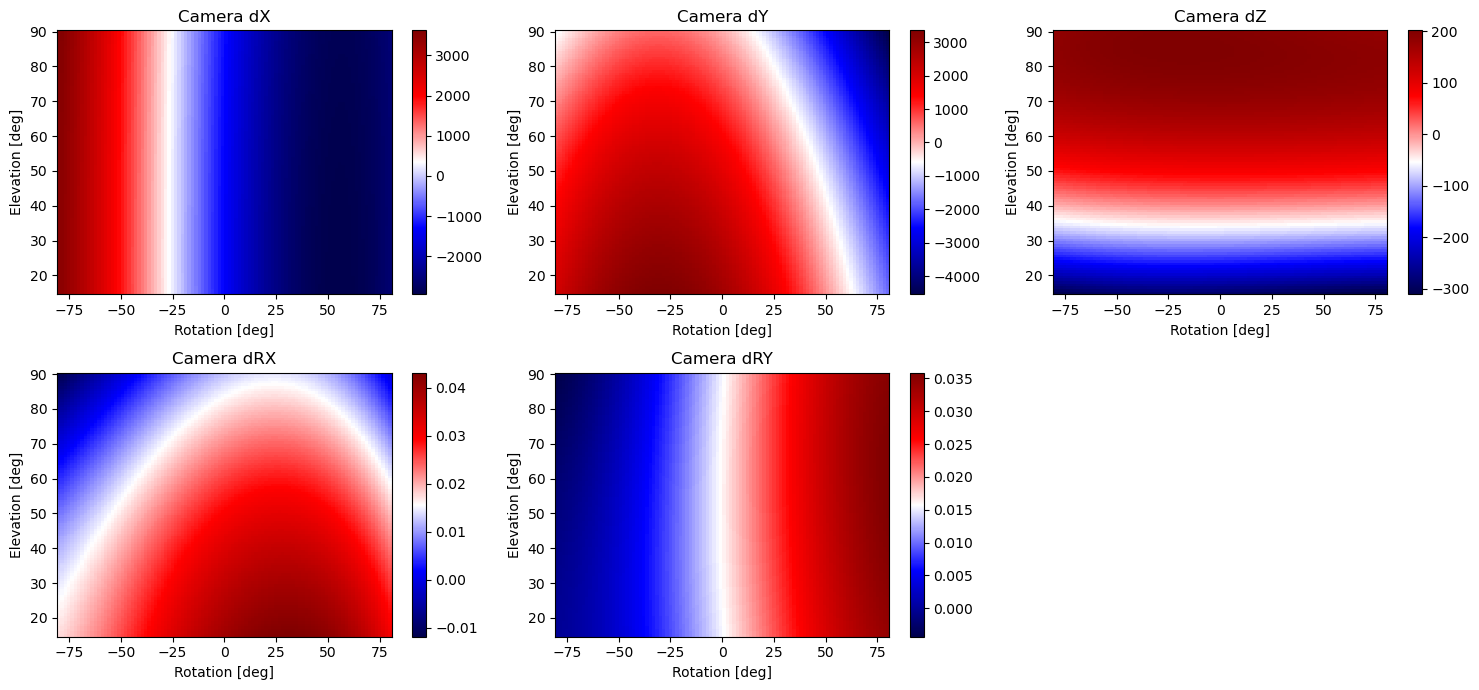

In [111]:
home_path = os.getenv("HOME")
# loading laser derived LUT
lut_path_update = os.path.join(
    home_path,
    "notebooks/lsst-ts/ts_config_mttcs/MTHexapod/v6/laser_rotation_elevation_v5.yaml",
)

with open(lut_path_update, "r") as yaml_file:
    lut_data = yaml.safe_load(yaml_file)
coeffs = lut_data["camera_config"]["elevation_rotation_coeffs"]


NUM_AXES = len(coeffs) - 1   # skip the trailing 0
elevation_rotation_polys = [
     partial(polyval2d, c=coeffs[i]) for i in range(NUM_AXES)
]

fields = ['dX', 'dY', 'dZ', 'dRX', 'dRY', 'dRZ','target']
el = np.linspace(15, 90, 100)  # elevation in degrees
rot = np.linspace(-80, 80, 100)  # rotation in degrees
EL, ROT = np.meshgrid(el, rot)

# Plot each axis
plt.figure(figsize=(15, 7))
for idx, poly in enumerate(elevation_rotation_polys):
    z = deepcopy(df[fields_n[idx]].to_numpy())
    if idx < 3:
        z *= 1000

    coeffs_fit = fit_poly2d(x, y, z, 3)
    Z_fit = polyval2d(EL, ROT, coeffs_fit)
    Z = polyval2d(EL, ROT, coeffs[idx])

    padded_zemax, padded_laser = pad_coeffs(np.array(coeffs_fit), np.array(coeffs[idx]))

    Z = polyval2d(EL, ROT, padded_laser)
    Z_total = polyval2d(EL, ROT, padded_zemax + padded_laser)

    print(f"{fields[idx]}: {padded_zemax + padded_laser}")
    print('--------------------')
    
    ax = plt.subplot(2, 3, idx + 1)
    surf = ax.pcolormesh(ROT, EL, Z + Z_fit, shading="auto", cmap="seismic")
    plt.colorbar(surf, ax=ax)
    ax.set_title(f"Camera {fields[idx]}")
    ax.set_xlabel("Rotation [deg]")
    ax.set_ylabel("Elevation [deg]")


plt.tight_layout()

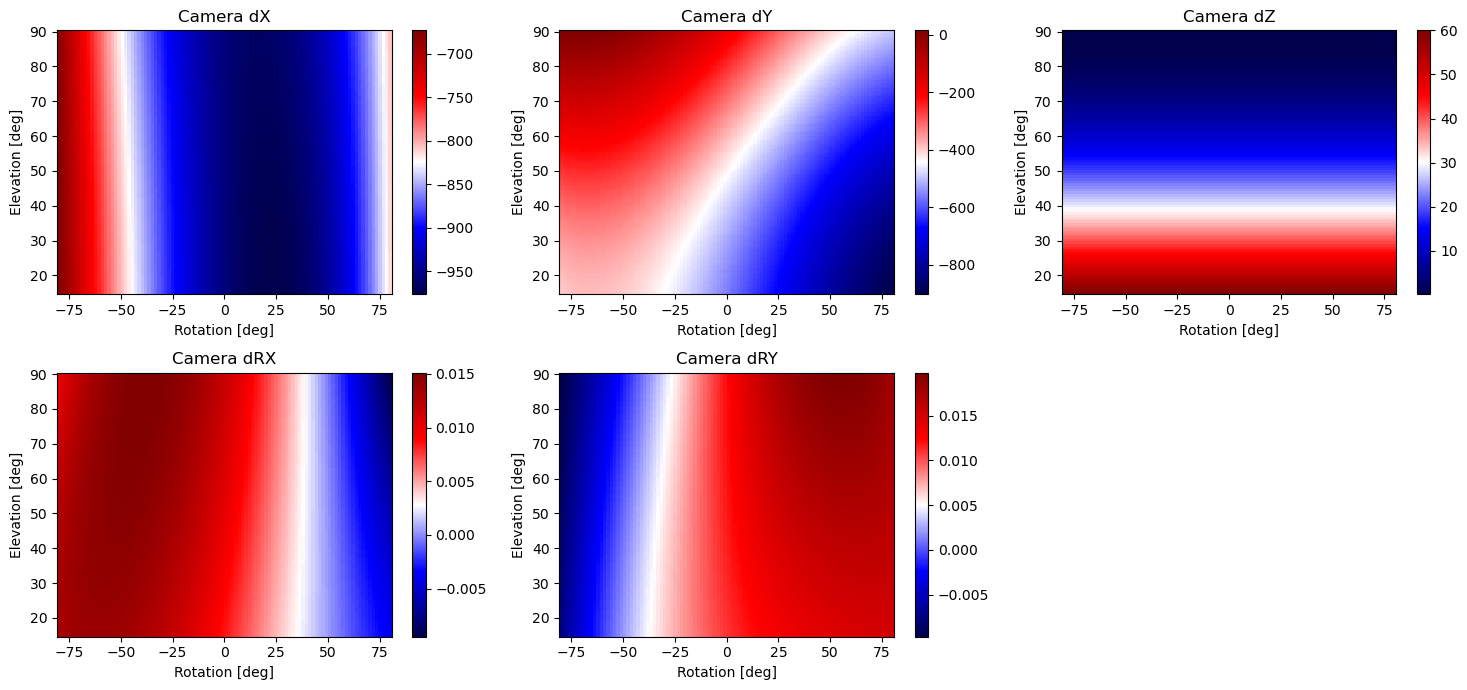

In [110]:
plt.figure(figsize=(15, 7))
for idx, poly in enumerate(elevation_rotation_polys):
    z = deepcopy(df[fields_n[idx]].to_numpy())
    if idx < 3:
        z *= 1000
    coeffs_fit = fit_poly2d(x, y, z, deg)
    Z_fit = polyval2d(EL, ROT, coeffs_fit)
    Z = polyval2d(EL, ROT, coeffs[idx])
    
    ax = plt.subplot(2, 3, idx + 1)
    surf = ax.pcolormesh(ROT, EL, Z_fit, shading="auto", cmap="seismic")
    plt.colorbar(surf, ax=ax)
    ax.set_title(f"Camera {fields[idx]}")
    ax.set_xlabel("Rotation [deg]")
    ax.set_ylabel("Elevation [deg]")

plt.tight_layout()